In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv('data/cs-training.csv')
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [23]:
df.shape
df.info()
df.isnull().sum()
df['SeriousDlqin2yrs'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [24]:
# Droping the unamed column
df = df.drop('Unnamed: 0' , axis = 1)

# Monthly income ki missing values ko fill kra ga 
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

# Number of dependant ki missing values ko fill kra ga 
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

df = df.drop_duplicates()
df.shape

df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [25]:
print(df.describe())

       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines            age  \
count     149233.000000                         149233.000000  149233.000000   
mean           0.067036                              6.077045      52.298145   
std            0.250085                            250.396053      14.714050   
min            0.000000                              0.000000       0.000000   
25%            0.000000                              0.030210      41.000000   
50%            0.000000                              0.154285      52.000000   
75%            0.000000                              0.555959      63.000000   
max            1.000000                          50708.000000     109.000000   

       NumberOfTime30-59DaysPastDueNotWorse      DebtRatio  MonthlyIncome  \
count                         149233.000000  149233.000000   1.492330e+05   
mean                               0.388386     354.808254   6.426774e+03   
std                                3.779712    2

In [26]:
# age wali rows sai kra ga jahan age 0 ya 0 sai kam ho
df = df[df['age']>0]

#98 placeholder ko drop kra ga blka above 90 sb ko hi drop kr da ga 
df = df[df['NumberOfTime30-59DaysPastDueNotWorse'] < 90]
df = df[df['NumberOfTime60-89DaysPastDueNotWorse'] < 90]
df = df[df['NumberOfTimes90DaysLate'] < 90]

df.shape


(149016, 11)

In [27]:
X = df.drop('SeriousDlqin2yrs', axis = 1)
Y = df['SeriousDlqin2yrs']

from sklearn.model_selection import train_test_split

X_train, X_test , Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42 , stratify = Y)

In [28]:
from sklearn.preprocessing import StandardScaler

# data to scale krna ka liya Standardscalar ka use kra ga
scalar = StandardScaler()

x_train_scaled = scalar.fit_transform(X_train)
x_test_scaled = scalar.transform(X_test)

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)

print('Before SMOTE: ', Y_train.value_counts())

x_train_resampled, y_train_resampled = smote.fit_resample(x_train_scaled, Y_train)

print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE:  SeriousDlqin2yrs
0    111314
1      7898
Name: count, dtype: int64
After SMOTE: SeriousDlqin2yrs
0    111314
1    111314
Name: count, dtype: int64


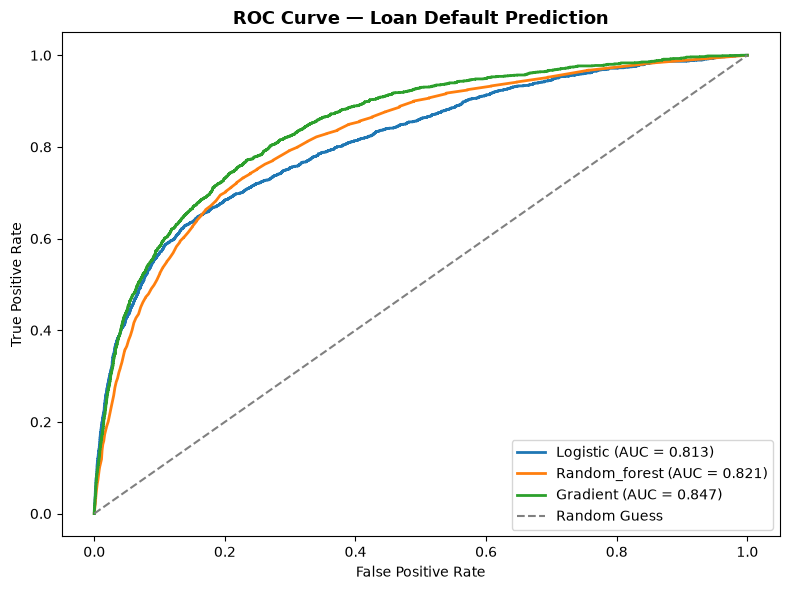

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, roc_auc_score
from sklearn.metrics import roc_curve


models = {
    "Logistic" : LogisticRegression(random_state = 42),
    "Random_forest" : RandomForestClassifier(random_state = 42),
    "Gradient" : GradientBoostingClassifier(random_state = 42)
}

results = []

for name , model in models.items():
    model.fit(x_train_resampled, y_train_resampled)
    y_pred = model.predict(x_test_scaled)
    y_proba = model.predict_proba(x_test_scaled)[:,1]

    results.append({
        "Model" : name,
        "accuracy" : accuracy_score(Y_test, y_pred),
        "precission" : precision_score(Y_test, y_pred),
        "recall" : recall_score(Y_test, y_pred),
        "f1_score" : f1_score(Y_test, y_pred),
        "roc_auc" : roc_auc_score(Y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values(by = 'roc_auc', ascending = False)
results_df


plt.figure(figsize = (8,6))

for name, model in models.items():
    y_proba = model.predict_proba(x_test_scaled)[:, 1]
    fpr, tpr , _ = roc_curve(Y_test, y_proba)
    auc_score = roc_auc_score(Y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Loan Default Prediction', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('images/roc_curve.png', dpi=300)
plt.show()

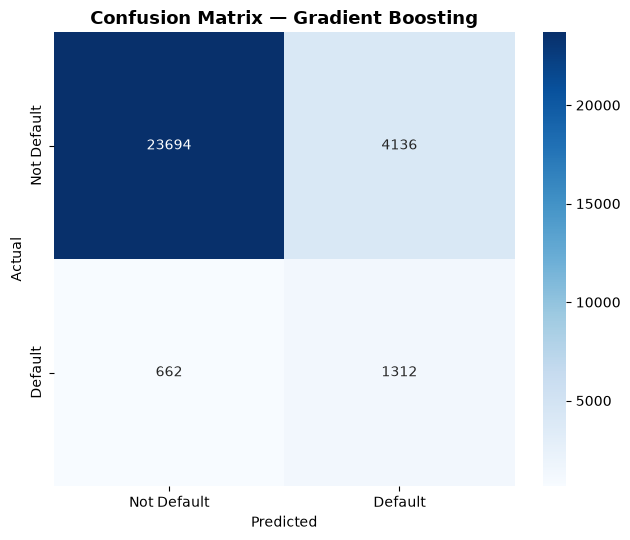

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_model = GradientBoostingClassifier(random_state=42)
best_model.fit(x_train_resampled, y_train_resampled)
y_pred = best_model.predict(x_test_scaled)

cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(6.5,5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Default','Default'],
            yticklabels=['Not Default','Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Gradient Boosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=200)
plt.show()

In [35]:
import joblib

joblib.dump(best_model, 'model_gradient_boosting.pkl')
joblib.dump(scalar, 'scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
